## 과제

### 패키지 불러오기

In [1]:
# 데이터 구성 패키지: Series, DataFrame
import pandas as pd
# 행렬 연산 패키지
import numpy as np

# 데이터 시각화 패키지
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석 패키지
from scipy import stats
import scipy.stats

In [2]:
# 한글 폰트(맑은 고딕) 적용 : 윈도우, 구글 콜랩
matplotlib.rc("font", family = "Malgun Gothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [3]:
# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

### 1) 실습 (기술통계) : 자동차 연비 Data Set에서 기술통계치 구하기
   - 시내에서 연비(mpg) 통계치: 구동방식별 데이터수, 평균, 중앙값, 표준편차, min, max, Q1, Q3
   - 고속도로에서 연비(mpg) 통계치 : 구동방식별 데이터수, 평균, 중앙값, 표준편차, min, max, Q1, Q3
( data.set : mycars.csv )

In [4]:
# mycars 데이터 가져오기
mycars = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\mycars.csv")
mycars.head()

,manufacturer,model,displacement,year,cylinder,automatic,driving,mpg,highway_mileage,fuel,class
0,audi,a4,1.8,1999,4,auto,f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual,f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual,f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto,f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto,f,16,26,p,compact


In [5]:
# 1. 시내에서 연비(mpg) 통계치: 구동방식별 데이터수, 평균, 중앙값, 표준편차, min, max, Q1, Q3
# --> 구동방식별!!! 구동방식으로 그룹을 만들어야함

df_cty = mycars[['driving', 'mpg']]
df_cty.groupby('driving').describe().round(3)

mpg                                             
         count    mean    std   min   25%   50%   75%   max
driving                                                    
4        103.0  14.330  2.874   9.0  13.0  14.0  16.0  21.0
f        106.0  19.972  3.627  11.0  18.0  19.0  21.0  35.0
r         25.0  14.080  2.216  11.0  12.0  15.0  15.0  18.0

In [6]:
# 2. 고속도로에서연비(mpg) 통계치 : 구동방식별 데이터수, 평균, 중앙값, 표준편차, min, max, Q1, Q3 

df_cty = mycars[['driving', 'highway_mileage']]
df_cty.groupby('driving').describe().round(3)

highway_mileage                                             
                  count    mean    std   min   25%   50%   75%   max
driving                                                             
4                 103.0  19.175  4.079  12.0  17.0  18.0  22.0  28.0
f                 106.0  28.160  4.207  17.0  26.0  28.0  29.0  44.0
r                  25.0  21.000  3.663  15.0  17.0  21.0  24.0  26.0

1. 데이터 추출 (Subset)  :  데이터프레임[['컬럼1', '컬럼2']]

2. 그룹화 : .groupby('driving')

3. 기술통계량 구하기  : .describe()

###  2) 실습_ 이산형_ 기술통계
  - 자동차의 모델과 연비(mpg)에 대한 자료를 조사한 Table입니다. 
  - 범주형 변수인 구동방식, 모델에 대해 counts, percents, cumulative counts, cumulative percents를 계산 바랍니다. 
  - ( data.set : mycars.csv )

In [7]:
# mycars 데이터 가져오기
mycars = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\mycars.csv")
mycars.head()

,manufacturer,model,displacement,year,cylinder,automatic,driving,mpg,highway_mileage,fuel,class
0,audi,a4,1.8,1999,4,auto,f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual,f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual,f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto,f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto,f,16,26,p,compact


In [8]:
#  구동방식, 모델에 대한 데이터 subset
df = mycars[['driving', 'model']]

- Flaws 변수 Count

In [9]:
# driving 변수 Count: value_counts(), 순서대로 정렬: .sort_index()
count = df['driving'].value_counts().sort_index()
count

4    103
f    106
r     25
Name: driving, dtype: int64

In [10]:
# Percent 계산: 직접
percent = count / sum(count) * 100
percent

4    44.017094
f    45.299145
r    10.683761
Name: driving, dtype: float64

In [11]:
# CumCnt(cumulative counts) 계산 : cumsum()
cumcnt = np.cumsum(count)
cumcnt

4    103
f    209
r    234
Name: driving, dtype: int64

In [12]:
# CumPct(cumulative percents) 계산: cumsum
cumpct = np.cumsum(percent)
cumpct

4     44.017094
f     89.316239
r    100.000000
Name: driving, dtype: float64

In [13]:
# DataFrame으로 취합
df_count = pd.DataFrame({'Count': count, 
                         'Percent': percent,
                         'CumCnt': cumcnt, 
                         'CumPct': cumpct})
df_count

,Count,Percent,CumCnt,CumPct
4,103,44.017094,103,44.017094
f,106,45.299145,209,89.316239
r,25,10.683761,234,100.000000


In [14]:
# Column의 name(좌측상단 이름) 생성
df_count.columns.name = 'driving'
df_count.round(2)

driving,Count,Percent,CumCnt,CumPct
4,103,44.02,103,44.02
f,106,45.30,209,89.32
r,25,10.68,234,100.00


- model 변수 Count

In [15]:
# Period 변수 Count: value_count, 순서대로 정렬: sort_index 
count2 = df['model'].value_counts().sort_index()
count2

4runner 4wd                6
a4                         7
a4 quattro                 8
a6 quattro                 3
altima                     6
c1500 suburban 2wd         5
camry                      7
camry solara               7
caravan 2wd               11
civic                      9
corolla                    5
corvette                   5
dakota pickup 4wd          9
durango 4wd                7
expedition 2wd             3
explorer 4wd               6
f150 pickup 4wd            7
forester awd               6
grand cherokee 4wd         8
grand prix                 5
gti                        5
impreza awd                8
jetta                      9
k1500 tahoe 4wd            4
land cruiser wagon 4wd     2
malibu                     5
maxima                     3
mountaineer 4wd            4
mustang                    9
navigator 2wd              3
new beetle                 6
passat                     7
pathfinder 4wd             4
ram 1500 pickup 4wd       10
range rover   

In [16]:
# Percent 계산: 직접
percent2 = count2 / sum(count2) * 100
percent2

4runner 4wd               2.564103
a4                        2.991453
a4 quattro                3.418803
a6 quattro                1.282051
altima                    2.564103
c1500 suburban 2wd        2.136752
camry                     2.991453
camry solara              2.991453
caravan 2wd               4.700855
civic                     3.846154
corolla                   2.136752
corvette                  2.136752
dakota pickup 4wd         3.846154
durango 4wd               2.991453
expedition 2wd            1.282051
explorer 4wd              2.564103
f150 pickup 4wd           2.991453
forester awd              2.564103
grand cherokee 4wd        3.418803
grand prix                2.136752
gti                       2.136752
impreza awd               3.418803
jetta                     3.846154
k1500 tahoe 4wd           1.709402
land cruiser wagon 4wd    0.854701
malibu                    2.136752
maxima                    1.282051
mountaineer 4wd           1.709402
mustang             

In [17]:
# CumCnt(cumulative counts) 계산 : cumsum
cumcnt2 = np.cumsum(count2)
cumcnt2

4runner 4wd                 6
a4                         13
a4 quattro                 21
a6 quattro                 24
altima                     30
c1500 suburban 2wd         35
camry                      42
camry solara               49
caravan 2wd                60
civic                      69
corolla                    74
corvette                   79
dakota pickup 4wd          88
durango 4wd                95
expedition 2wd             98
explorer 4wd              104
f150 pickup 4wd           111
forester awd              117
grand cherokee 4wd        125
grand prix                130
gti                       135
impreza awd               143
jetta                     152
k1500 tahoe 4wd           156
land cruiser wagon 4wd    158
malibu                    163
maxima                    166
mountaineer 4wd           170
mustang                   179
navigator 2wd             182
new beetle                188
passat                    195
pathfinder 4wd            199
ram 1500 p

In [18]:
# CumPct(cumulative percents) 계산: cumsum
cumpct2 = np.cumsum(percent2)
cumpct2

4runner 4wd                 2.564103
a4                          5.555556
a4 quattro                  8.974359
a6 quattro                 10.256410
altima                     12.820513
c1500 suburban 2wd         14.957265
camry                      17.948718
camry solara               20.940171
caravan 2wd                25.641026
civic                      29.487179
corolla                    31.623932
corvette                   33.760684
dakota pickup 4wd          37.606838
durango 4wd                40.598291
expedition 2wd             41.880342
explorer 4wd               44.444444
f150 pickup 4wd            47.435897
forester awd               50.000000
grand cherokee 4wd         53.418803
grand prix                 55.555556
gti                        57.692308
impreza awd                61.111111
jetta                      64.957265
k1500 tahoe 4wd            66.666667
land cruiser wagon 4wd     67.521368
malibu                     69.658120
maxima                     70.940171
m

In [19]:
# DataFrame으로 취합 
df_count2 = pd.DataFrame({'Count': count2,
                          'Percent': percent2,
                          'CumCnt': cumcnt2, 
                          'CumPct': cumpct2})

# Column의 name(좌측상단 이름) 생성 
df_count2.columns.name='model'
df_count2.round(2)

model,Count,Percent,CumCnt,CumPct
4runner 4wd,6,2.56,6,2.56
a4,7,2.99,13,5.56
a4 quattro,8,3.42,21,8.97
a6 quattro,3,1.28,24,10.26
altima,6,2.56,30,12.82
c1500 suburban 2wd,5,2.14,35,14.96
camry,7,2.99,42,17.95
camry solara,7,2.99,49,20.94
caravan 2wd,11,4.70,60,25.64
civic,9,3.85,69,29.49


### 3) 실습 (정규분포 확률계산)
- 대한민국 남성의 20~30대 키를 측정한 결과, 평균 175cm, 표준편차 5cm 이다.
- 나의 키가 180cm 일 경우에 나는 몇 % 범위에 위치할까요?

평균 ($\mu$): 175cm  

표준편차 ($\sigma$): 5cm  

기준값 ($x$): 180cm

In [20]:
# 정규분포에서 누적확률 값 계산
x = 180
mu = 175
sigma = 5

# prob : 키가 180cm 일 경우 누적확률값 계산
prob = stats.norm.cdf(x, mu, sigma)

In [21]:
# 나의 키가 180cm 일 경우에 나는 몇 % 범위에 위치할까요?
print(" 나의 키가 {0} 일 경우에 나는 {1:.1f}% 범위에 위치합니다.".format(x, (1-prob)*100))

 나의 키가 180 일 경우에 나는 15.9% 범위에 위치합니다.


### 4) 실습 (정규분포 확률계산)
  - 어떤 자동차 1리터당 주행거리가 평균 12km, 표준편차 3km인 정규분포를 이룬다. 
  - 1리터를 가지고 9km 이상 15km 이하를 달릴 확률은 얼마인가?
  - 1리터를 가지고 15km 이상을 달릴 확률은 얼마인가?

In [22]:
# 누적확률 값 계산
mu = 12
sigma = 3

# 15km 이하일 누적 확률 계산
prob_15 = stats.norm.cdf(15, mu, sigma)

# 9km 이하일 누적 확률 계산
prob_9 = stats.norm.cdf(9, mu, sigma)

In [23]:
# (15km까지의 넓이 - 9km까지의 넓이)
ans1 = (prob_15 - prob_9) * 100
print("1 리터를 가지고 9km ~ 15km 달릴 확률: {0:.1f}%".format(ans1))

1 리터를 가지고 9km ~ 15km 달릴 확률: 68.3%


In [24]:
# (전체 1 - 15km까지의 넓이)
ans2 = (1 - prob_15) * 100
print("15km 이상 달릴 확률: {0:.1f}%".format(ans2))

15km 이상 달릴 확률: 15.9%


### 5)  실습 (t 분포)
  - 확률변수 t는 자유도가 100인  t-분포를 따른다.
  -  t 값이 2.0일 때,  P (T ≤ t)을 계산하시오

#### t 분포 문제 stats.t.cdf()

In [25]:
# t 분포 확률 계산하기
t = 2.0
df = 100

# 누적확률 값 계산
prob = stats.t.cdf(t, df)
print(" P(T<=t)= {:.1f}%".format(prob*100))

 P(T<=t)= 97.6%


자유도가 100인 t 분포에서 t 값이 2.0보다 작을 확률이 97.6%이다 라는 뜻

### 6) 실습 (χ2 분포, 확률 계산)
  - 확률변수 χ2 는 자유도가 8 인 χ2 -분포를 따른다. 
  - χ2 값이  3.0 일 때,  P (X ≤ χ2 )을 계산하시오.

#### 카이제곱 분포용 함수인 stats.chi2.cdf()

In [26]:
# χ2 분포, 확률 계산하기
chisq = 3.0
df = 8

# 누적확률 값 계산
prob = stats.chi2.cdf(chisq, df)
print("χ2 누적확률 계산 : p(X<={0}) = {1:.4f}".format(chisq, prob))

χ2 누적확률 계산 : p(X<=3.0) = 0.0656


#### 결론 : P값이 0.065 -> 3.0 이하의 값이 나올 확률이 매우 낮다는 것

### 7) 실습 (F 분포, 확률 계산)
  - 확률변수 F 는 각각 자유도가 10, 100 인  F-분포를 따른다.
  -  F 값이 1.5 일 때,  P (X ≤ F)을 계산하시오.

In [27]:
# F 분포, 확률 계산하기
f = 1.5
df_num = 10     #Numerator : 분자의 자유도
df_den = 100    #Denominator : 분모의 자유도

# 누적확률 값 계산
prob = stats.f.cdf(f, df_num, df_den)
print("P(X <= F): {:.3f}".format(prob))

P(X <= F): 0.850


##### 데이터의 대부분(85%)이 어디에 위치하는지 확인

이 F-분포에서 1.5보다 작거나 같은 값이 나올 확률이 85%이다

### 8) 실습 (이항 분포)
   - 도장공정에서 광택도 불량이 30%나 된다고 함
   - 5대의 차량을 임의로 선택했을 때 불량대수가 각각 0, 1, 2, 3, 4, 5 대가 나올 확률은 얼마인가

In [28]:
# 이항분포에서 확률 계산하기 : pmf(k,n,p) 
n = 5      # n : 3대의 차량 수
p = 0.3    # 공정 불량

for i in range(n+1) :                       # range는 0 이상 n+1 미만
   # 이항분포 Probability Mass Function
    prob = stats.binom.pmf(k=i, n=n, p=p)  
    print("P(X={0}) = {1:.3f}".format(i, prob))

P(X=0) = 0.168
P(X=1) = 0.360
P(X=2) = 0.309
P(X=3) = 0.132
P(X=4) = 0.028
P(X=5) = 0.002


## 1.Big Data분석기초_연습_04_탐색적분석_통계

### 패키지 불러오기

In [29]:
# 가설검정 및 통계 분석 패키지
import scipy.stats as stats
from statsmodels.formula.api import ols

# proportion test 패키지
from statsmodels.stats.proportion import proportions_ztest

# ANOVA 분석 패키지
from statsmodels.stats.anova import anova_lm

### 9) 실습 (정규성 검정)
   - 실습파일 2sample_t_test.csv 을 불러온다
   - 변수, Mat_A와 Mat_B에 대해 각각 정규성을 검정합니다

In [30]:
# 2sample_t_test.csv  가져오기
df = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\2sample_t_test.csv")
df.head()

,Mat_A,Mat_B
0,73.4,68.7
1,77.0,71.4
2,73.7,69.8
3,73.3,75.3
4,73.1,71.3


- 정규성 검정 

정규성 검정 : stats.shapiro()

In [31]:
# 정규성 검정 : Shapiro-Wilk Test
statistic, p = stats.shapiro(df['Mat_A'])

print("Shapiro-Wilk Test: statistic={}, p-value={}".format(statistic, p))

Shapiro-Wilk Test: statistic=0.9062639000665075, p-value=0.2563008675689954


P-value가 0.256입니다.  
0.256 > 0.05이므로 귀무가설을 기각하지 못함, 오류가 날 가능성이 25퍼 라는 말  
결론: 귀무가설 채택! -> 정규분포 맞음. = Mat_A 데이터는 정규성을 만족한다.

In [32]:
# 정규성 검정 : Shapiro-Wilk Test
statistic, p = stats.shapiro(df['Mat_B'])

print("Shapiro-Wilk Test: statistic={}, p-value={}".format(statistic, p))

Shapiro-Wilk Test: statistic=0.9729754651286565, p-value=0.916978399513421


P-value가 0.916입니다.  
0.916 > 0.05이므로 귀무가설을 기각하지 못함, 오류가 날 가능성이 91퍼 라는 말  (큰 일)
결론: 귀무가설 채택! -> 정규분포 맞음. = Mat_B 데이터는 정규성을 만족한다.

### 10) 실습 모평균 구간추정 (모표준편차 알 때)
   - 새로운 품종의 감자 20 Box를 랜덤추출하여 무게를 측정할 결과가 다음과 같음
   - (단, 모표준편차는 3.8로 알려져 있음) 이 자료로부터 신품종 배추의 평균 무게에 대한 95% 신뢰구간을 구하시오.

stats.norm.interval() : 정규분포를 가정하고 특정 신뢰수준(95%)에 해당하는 구간을 찾아주는 함수    
옵션  
0.95: 신뢰수준 95%를 의미합니다.  
loc: 위치(Location), 즉 표본평균을 넣는 자리입니다.  
scale: 규모(Scale), 즉 표준오차($\frac{\sigma}{\sqrt{n}}$)를 넣는 자리입니다.

In [33]:
# 데이터 직접입력
df = pd.DataFrame({'wgt':[18, 18, 20, 21, 20, 23, 19, 18, 17, 21, 
                          22, 20, 20, 21, 20, 19, 19, 18, 17, 19]})

# 데이터 확인
df.head()

,wgt
0,18
1,18
2,20
3,21
4,20


In [34]:
# 정규분포 구간 추정 함수 실행 

lower, upper = stats.norm.interval(0.95, loc = np.mean(df), scale = 3.8/np.sqrt(20))
print("신뢰구간: ({0}, {1})" .format(lower.round(2), upper.round(2)))

신뢰구간: ([17.83], [21.17])


### 11) 실습 모평균 구간추정(모표준편차 모를 때)
   - 제품개발자는 새로 개발된 강종의 평균 인장강도를 70 kg/mm2으로 기대하고 있음. 이를 검증하기 위해 시험 생산되는 강종 중 임의로 20개의 코일을 대상으로 랜덤하게 시편을 채취하였음. 
   - 상기 자료로부터 표본평균은 71.50 kg/mm2, 표본표준편차는 1.933 kg/mm2 임을 알았음.  이 모평균값의 95% 신뢰구간을 추정하시오.

In [35]:
# 직접 입력
df = pd.DataFrame({'streng':[54.1, 53.3, 56.1, 55.7, 54.0, 54.1, 54.5, 57.1, 55.2, 53.8, 
                             54.1, 54.1, 56.1, 55.0, 55.9, 56.0, 54.9, 54.3, 53.9, 55.0]})

# 데이터 확인
df.head()

,streng
0,54.1
1,53.3
2,56.1
3,55.7
4,54.0


In [36]:
# 신뢰구간 내기 전에, 나의 진짜 점수(평균)가 몇 점인지 궁금할떄 점추정 값 구해보기 그냥 한 번 해봄
df.mean()

streng    54.86
dtype: float64

In [37]:
# t 분포 구간추정 함수 실행 : (loc: 평균의 값, scale: 변동 정도)  
lower, upper = stats.t.interval(0.95, len(df)-1, loc = np.mean(df), scale = stats.sem(df))
lower.round(2), upper.round(2)

(array([54.39]), array([55.33]))

#### stats.t.interval (t-분포) 함수 사용하는 경우
- 모표준편차($\sigma$)를 모를 때
- 데이터 개수가 적을 때

### 12) 실습 1-Sample t-test : 모표준편차를 모를 때
   - 고객서비스센터의 고객만족도 평균은 78.0이다. 개선활동을 완료한 후 다음과 같은 10개의 고객만족도 데이터를 얻었다. 개선활동이 만족도를 변화시켰는가? ( α =0.05 )
   - 데이터 : 85.0 79.0 79.1 79.9 81.6 78.6 85.4 83.4 78.1 79.2

귀무가설 : 드라마 같은거 : 개선 활동 의미 없다   
대립가설 : 변화가 생겼습니다 ~

In [38]:
# 데이터 직접 입력
df = pd.DataFrame({'satisfaction': [85.0, 79.0, 79.1, 79.9, 81.6, 78.6, 85.4, 83.4, 78.1, 79.2]})

# 데이터 확인
df.head()

,satisfaction
0,85.0
1,79.0
2,79.1
3,79.9
4,81.6


<Axes: >

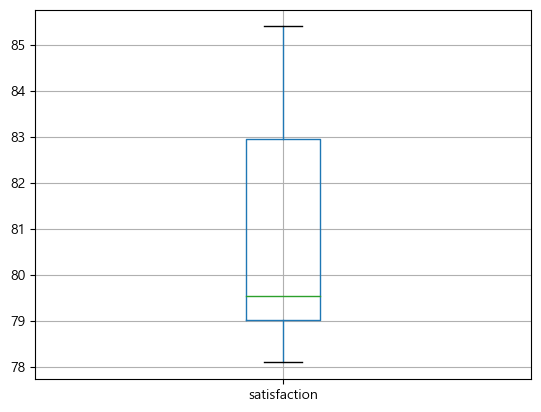

In [39]:
# boxplot
df.boxplot()

이상치 없어보임

In [40]:
# satisfaction 정규성 검정: Shapiro-Wilk Test
statistic, p = stats.shapiro(df['satisfaction'])
print("statistic={}, p-value={}".format(statistic,p))

statistic=0.8473218074095161, p-value=0.05397528806783875


P 값이 0.053으로 0.05 이상이다 대립가설 통과 (정규성)  
정규성 통과  = 우리 데이터는 정규분포를 따른다  
t-test 하자  

#### 1-Sample t-test : stats.ttest_1samp 함수

In [41]:
# 1-Sample t-test
t_result = stats.ttest_1samp(df, 78.0)

In [42]:
# 1-Sample t-test의 t값 p값 저장
t, p = t_result.statistic.round(3), \
       t_result.pvalue.round(3)

In [43]:
# 1-Sample t-test의 t값  p값 출력
print( "1-Sample t-test ")
print( " t 통계량 : {} " .format(t))
print( " p-value : {} " .format(p))

1-Sample t-test 
 t 통계량 : [3.379] 
 p-value : [0.008] 


P값이 0.008로 0.05보다 작다 오류가 생길 가능성이 희박하다  
대립가설 채택 => 변화가 있었다!  
개선 활동 덕분에 만족도에 변화가 생겼다.

### 13) 실습 2 Sample t-test : 두 집단 간 평균이 같은지 비교 
   - 제품을 A공급자과 B공급자로 부터 제품을 받아 두께를 측정해서 다음의 데이터를 얻었다. 공급자 간에 모평균에 차이가 있다고 할 수 있는가? (유의수준 α = 0.05)

- 질문에서 차이가 있다고 할 수 있는가? (긍)
- 귀무가설 : 평균 두께에 차이가 없다 (부)
- 대립가설 : 있다 (긍)   
...약간 추구미가 대립가설...

In [44]:
# 데이터 입력
df = pd.DataFrame({
    'A': [1.883, 1.715, 1.799, 1.768, 1.711, 1.832, 1.427, 1.344],
    'B': [1.435, 1.572, 1.486, 1.511, 1.457, 1.548, 1.404, 1.800]
})

# 데이터 확인
df.head()

,A,B
0,1.883,1.435
1,1.715,1.572
2,1.799,1.486
3,1.768,1.511
4,1.711,1.457


순서 : 정규성 검정 -> 등분산 검정 -> t-test 실행 (등분산이면)

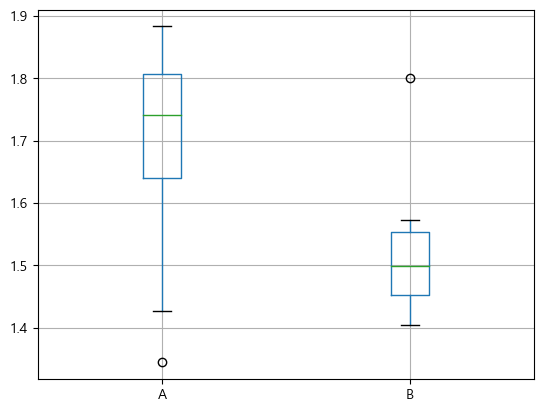

In [45]:
# Group별 boxplot
df.boxplot(['A','B'])
plt.show()

이상치 없음

In [46]:
# ‘A‘, ‘B’ 정규성 검정: Shapiro-Wilk Test
statistic, p = stats.shapiro(df['A'])
print("statistic={}, p-value={}".format(statistic,p))

statistic=0.8425755349628155, p-value=0.08004540790335968


In [47]:
statistic, p = stats.shapiro(df['B'])
print("statistic={}, p-value={}".format(statistic,p))

statistic=0.8393933531403902, p-value=0.07424861689729985


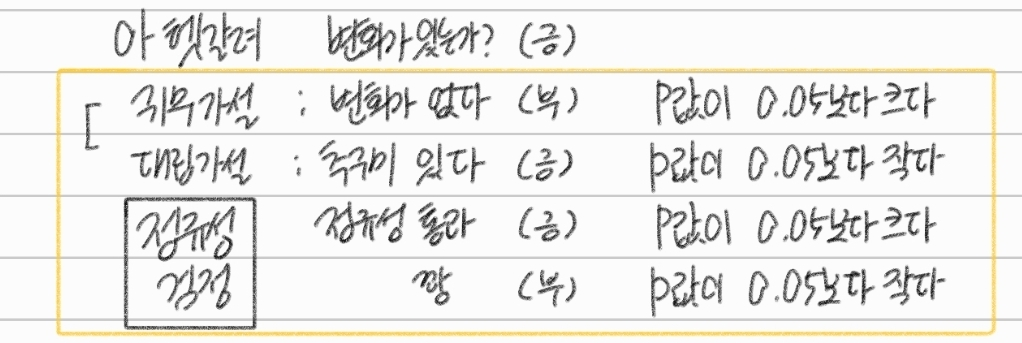

p값이 0.08로 0.05보다 높음 바꾸면 오류가 날 가능성이 있다  
귀무가설을 채택하자  == 정규분포를 따른다


In [48]:
# 등분산성 검정
stats.bartlett(df['A'], df['B'])

BartlettResult(statistic=1.2899966318541203, pvalue=0.25604857136527204)

P=0.256으로 0.05보다 훨씬 큽니다.  
"두 집단의 분산이 같다"는 귀무가설 채택! 

In [49]:
# 2-Sample t-test
t_result = stats.ttest_ind(df['A'], df['B'])

# 2-Sample t-test의 t값 p값 저장
t, p = t_result.statistic.round(3), t_result.pvalue.round(3)

In [50]:
# 2-Sample t-test의 t값 p값 출력
print( "2-Sample t-test ")
print( " t: {} " .format(t))
print( " p: {} " .format(p))

2-Sample t-test 
 t: 1.94 
 p: 0.073 


최종 2-Sample t-test:  
P-value = 0.073이 나왔습니다.  
오류가 날 가능성이 7퍼 귀무가설을 기각할 수 없다.

#### 공급자 A와 B의 평균 두께에는 통계적으로 유의미한 차이가 있다고 할 수 없다


### 14) 실습 Paired t-test : 짝을 이루는 집단의 평균의 차이가 있는지 검정
   - 회사원 10명에 대해 영어점수가 학원가기 전/후에 영어점수가 짝을 이루고 있다. 회사원들의 성적은 학원가기 전후에 대해 차이가 있는지 검정하라. (유의수준 α = 0.05)

In [51]:
df1 = pd.DataFrame({'before': [720, 589, 780, 648, 720, 589, 780, 648, 780, 648]})
df2 = pd.DataFrame({'after': [810, 670, 790, 712, 810, 670, 790, 712, 790, 712]})

t_result = stats.ttest_rel(df1, df2)

# Paired t-test의 t값 p값 저장
t, p = t_result.statistic.round(3), t_result.pvalue.round(3)

In [52]:
# Paired t-test의 t값 p값 출력
print( "Paired t-test ")
print( " t: {} " .format(t))
print( " p: {} " .format(p))

Paired t-test 
 t: [-5.324] 
 p: [0.] 


df1 (학원 전) - df2 (학원 후) = 결과가 t 인데 마이너스임  
--> 학원 후에 성적이 올랐다는 뜻  

p-value가 0.05보다 훨씬 작다 귀무가설(차이가 없다)을 기각한다 바꿔도 오류가 나지 않기 때문이다.  
--> 학원 후에 성적이 올랐다는 뜻 

### 차이가 있다!

### 15) 실습 1 Proportion test
   - 동전이 정상적인가를 검정하기 위해 100번을 던져본 결과, 앞면이 40번 나왔으며 뒷면이 60번 나왔다. 이 동전은 정상인가를 유의수준 =0.05로써 검정하라. 정상적인 동전을 던질 때, 앞면이 나올 확률은 50%이다. 

- 1 Proportion test

In [53]:
# 가설 수립

# 변수 선언 
count = 40      #40번 앞면 나옴
n_obs = 100     #100번 던짐
value = 0.5     #50퍼

# Proportion test 실행
z, p = proportions_ztest(count, n_obs, value)

In [54]:
# Proportion test 결과 출력
print( "1 Proportion test ")
print( ' z: {0:0.3f}' .format(z))
print( ' p: {0:0.3f}'.format(p))

1 Proportion test 
 z: -2.041
 p: 0.041


P 값이 우리가 정한 기준인 0.05보다 작다    
귀무가설 기각 대립 가설 채택  
대립가설 : 차이가 있다. = 이 동전은 뭔가 수상하다.  

z의 절대값이 커서 차이가 있다

### 결론 : 이 동전은 수상하다 정상적인 동전이 아니다.

### 16) 실습 2 Proportion test
   - 동일한 제품을 생산하는 두 공장에서 불량률을 측정한 결과 아래와 같다. 두 공정의 불량률이 같다고 할 수 있는가? (유의수준()=0.05)
- 공장 A : N1 = 1200 , X1 = 14 
- 공장 B : N2 = 1200 , X2 = 5

- 2 Proportion test

In [55]:
# 귀무가설(H0): "두 공장의 불량률은 차이가 없다." (공장 A = 공장 B)
# 대립가설(Ha): "두 공장의 불량률은 차이가 있다." (공장 A != 공장 B)
# 변수 선언 
count = np.array([14, 5])
nobs = np.array([1200, 1200])

# Proportion test 실행
z, p = proportions_ztest(count, nobs)

In [56]:
# Proportion test 결과 출력
print( "2 Proportion test ")
print( ' z: {0:0.3f}' .format(z))
print( ' p: {0:0.3f}'.format(p))

2 Proportion test 
 z: 2.073
 p: 0.038


 0.038 < 0.0 이므로 귀무가설 기각! -> 대립: 차이가 있다   
 z의 절대값이 커서 차이가 있다 
 ### 결론 : 두 공장의 불량률이 같다고 할 수 없다. 

### 17) 실습 카이제곱 검정, chi-square test
   - 노트북 컴퓨터의 6가지 제품(A, B, C, D, E, F)에 대하여 7가지 제품의 이미지를 중복 선택할 수 있도록 32 명의 소비자를 대상으로 설문 조사한 Table이다. 각 제품에 대해 이미지에 대해 차이가 있겠는가? (유의수준 0.05)

- 귀무가설 : 차이가 없다.
- 대립가설 : 차이가 있다.

In [57]:
df = pd.DataFrame({
    'A': [18, 1, 8, 7, 10, 9, 10],
    'B': [8, 2, 14, 5, 5, 9, 4],
    'C': [4, 1, 3, 4, 9, 5, 4],
    'D': [4, 1, 2, 3, 2, 7, 3],
    'E': [3, 1, 3, 1, 1, 1, 1],
    'F': [3, 25, 8, 10, 2, 1, 7]
}, index=['A/S', '가격', '성능', '확장성', '디자인', '안정성', '기능성'])

# chi-square test 실행

chi, pval, dof, expected = stats.chi2_contingency(df)

# chi-square test 결과 출력
print("chi-square test")
print(' chisq: {0:0.3f}'.format(chi))
print(' p: {0:0.3f}'.format(pval))
print(' degree of freedom: {}'.format(dof))
print(' expected value: \n{}'.format(expected.round(3)))

chi-square test
 chisq: 98.274
 p: 0.000
 degree of freedom: 30
 expected value: 
[[11.004  8.21   5.24   3.843  1.921  9.782]
 [ 8.528  6.362  4.061  2.978  1.489  7.581]
 [10.454  7.799  4.978  3.651  1.825  9.293]
 [ 8.253  6.157  3.93   2.882  1.441  7.336]
 [ 7.978  5.952  3.799  2.786  1.393  7.092]
 [ 8.803  6.568  4.192  3.074  1.537  7.825]
 [ 7.978  5.952  3.799  2.786  1.393  7.092]]


P 값이 그냥 0임 차이가 있다.  
카이제곱 값이 아주 크다 => 아주 아주 유의미한 차이가 있다.    
귀무가설 기각! 대립가설 채택!

### 결론: 각 제품(A~F)에 대해 소비자들이 느끼는 이미지에는 통계적으로 유의미한 차이가 있다.


### 18) 실습 ANOVA
   - 철강의 청정도를 높이기 위해 제강공정에서 2차 정련을 실시하는데, 강종별로 2차 정련시간의 차이가 있는지와 type별로 2차정련 시간에 차이가 있는지 검정하라 (유의수준 0.05) ( data set : ANOVA.csv)

2차 정련 에서  
타입/2차 정련 시간에 따라 차이가 있는가?  
귀무가설 : 없다  
대립가설 : 있다

In [58]:
# ANOVA 데이터 가져오기
ANOVA = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\ANOVA.csv")
ANOVA   #아 gangjong이 a, b, c, d 있다!@

,time,charge,gangjong,type
0,32.2,A,a,a
1,30.4,B,a,a
2,33.6,C,a,a
3,36.4,D,a,a
4,33.9,E,a,a
5,34.9,F,a,a
6,33.1,A,b,a
7,29.9,B,b,a
8,31.7,C,b,a
9,27.5,D,b,a


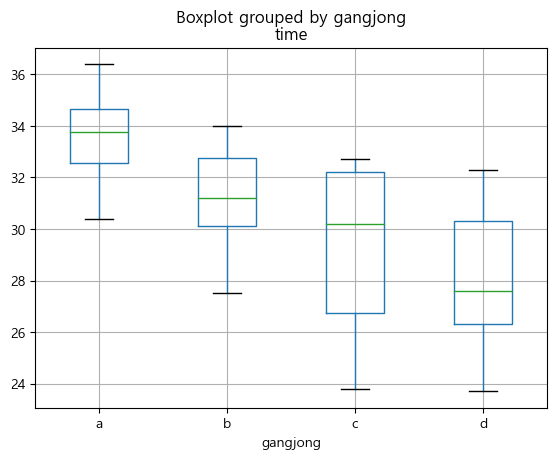

In [59]:
ANOVA.boxplot(column='time', by='gangjong')
plt.show()

강종 a가 다른 강종에 비해 좀 다르다

In [60]:
# 'a', 'b', 'c', 'd' 정규성 검정: Shapiro-Wilk Test
# 강종별로 데이터를 추출하여 검정을 진행합니다.
f, p = stats.shapiro(ANOVA[ANOVA['gangjong'] == 'a']['time'])
print("강종 a statistic={}, p-value={}".format(f, p))

f, p = stats.shapiro(ANOVA[ANOVA['gangjong'] == 'b']['time'])
print("강종 b statistic={}, p-value={}".format(f, p))

f, p = stats.shapiro(ANOVA[ANOVA['gangjong'] == 'c']['time'])
print("강종 c statistic={}, p-value={}".format(f, p))

f, p = stats.shapiro(ANOVA[ANOVA['gangjong'] == 'd']['time'])
print("강종 d statistic={}, p-value={}".format(f, p))

강종 a statistic=0.9879402484638727, p-value=0.9835576371370772
강종 b statistic=0.9769708531514716, p-value=0.9355481069537137
강종 c statistic=0.8929418389400074, p-value=0.33388968261479385
강종 d statistic=0.9713903657895416, p-value=0.901640794517041


모든 강종(a, b, c, d)의 P값이 0.05보다 훨씬 크다 : 정규분포를 따르고 있다!

In [61]:
# 'a', 'b', 'c', 'd' 등분산성 검정: bartlett Test
stats.bartlett(ANOVA[ANOVA['gangjong'] == 'a']['time'],
               ANOVA[ANOVA['gangjong'] == 'b']['time'],
               ANOVA[ANOVA['gangjong'] == 'c']['time'],
               ANOVA[ANOVA['gangjong'] == 'd']['time'])

BartlettResult(statistic=1.8729084232387967, pvalue=0.5991991808067023)

0.59 ! 0.005 보다 훨씬 크다 

### 등분산성 검정 결과: 강종의 데이터가 퍼진 정도가 비슷비슷하다.

In [62]:
# ANOVA 실행
f_result = stats.f_oneway(ANOVA[ANOVA['gangjong'] == 'a']['time'],
                          ANOVA[ANOVA['gangjong'] == 'b']['time'],
                          ANOVA[ANOVA['gangjong'] == 'c']['time'],
                          ANOVA[ANOVA['gangjong'] == 'd']['time'])

In [63]:
# ANOVA의 f값 p값 저장
f, p = f_result.statistic.round(3), \
       f_result.pvalue.round(3)

In [64]:
# ANOVA의 f값 p값 출력
print( "One-way ANOVA" )
print( " F 통계량 : {} " .format(f))
print( " p-value : {} " .format(p))

One-way ANOVA
 F 통계량 : 4.172 
 p-value : 0.019 


어 대박 강종은 정련 시간에 영향을 준다. P값이 0.05보다 작다 -> 대립 가설 채택 

### ANOVA 실행 결과: 강종 따라 2차 정련 시간은 유의미한 차이가 있다!!!

### 19) 실습  Correlation Analysis
   - 초코칩의 강도와 재료 반죽온도간에 관계를 분석하기 위한 상관분석을 하세요

귀무 가설 : 상관관계가 없다.  
대립 가설 : 상관관계가 있다.

In [65]:
strength = [37.6, 38.6, 37.2, 36.4, 38.6, 39, 37.2, 36.1, 35.9, 37.1, 
            36.9, 37.5, 36.3, 38.1, 39, 36.9, 36.8, 37.6, 33, 33.5]
            
temperature = [14, 15, 14, 16, 17, 14, 17, 16, 15, 16, 
               14, 16, 18, 13, 15, 17, 14, 16, 20, 21]

#  Correlation Analysis 실행
corr, pval = stats.pearsonr(strength, temperature)

#  Correlation, p-value 결과 출력 
print("Correlation Analysis")
print(' corr: {0:0.3f}'.format(corr))
print(' p-value : {0:0.3f}'.format(pval))

Correlation Analysis
 corr: -0.723
 p-value : 0.000


#### corr (상관계수):   1이나 -1에 가까울수록 아주 강력한 관계입니다.
- #+ 값이면: 온도가 높을수록 강도도 높아짐 (정의 관계)
- #- 값이면: 온도가 높을수록 강도는 낮아짐 (부의 관계)

P 값도 0.05보다 작다! : 차이가 있다!!

#### 결론 : 초코칩의 강도와 반죽 온도 사이에는 통계적으로 유의미한 강한 음(-)의 상관관계가 있다, 이는 온도가 높아질수록 초코칩의 강도가 약해지는 경향이 있음을 의미한다.

맛있는 초코칩을 위해 온도 조절을 조심해라  
- 양(+)의 관계였다면: "온도가 뜨거워질수록 초코칩이 더 단단(강도 강)했을것임

| 분석 종류 | 사용하는 함수 | 언제 사용하는가? (목적) | 예시 상황 |
|------|---|---|---|
| 정규성 검정 | `shapiro(data)` | 데이터가 정규분포(종 모양)를 따르는지 확인 | ANOVA나 t-test 수행 전 정규성 확인 |
| 등분산 검정 | `bartlett(g1, g2, ...)` | 집단 간 분산(퍼진 정도)이 같은지 확인 | 2-sample t-test, ANOVA 수행 전 확인 |
| 2-Sample t-test | `ttest_ind(g1, g2)` | 서로 다른 두 집단의 평균 차이 검정 | 공급자 A와 B의 제품 두께 비교 |
| Paired t-test | `ttest_rel(before, after)` | 동일 대상의 전/후 평균 차이 검정 | 학원 수강 전/후 성적 비교 |
| 1 Proportion Test | `proportions_ztest(c, n, v)` | 한 집단의 비율이 기준값과 같은지 확인 | 동전 앞면 확률이 50%인지 확인 |
| 2 Proportion Test | `proportions_ztest(counts, nobs)` | 두 집단의 비율 차이 검정 | 공장 A와 B의 불량률 비교 |
| Chi-square Test | `chi2_contingency(df)` | 범주형 변수 간 연관성 확인 | 브랜드별 선호 이미지 차이 확인 |
| ANOVA | `f_oneway(g1, g2, g3, ...)` | 세 집단 이상의 평균 차이 검정 | 강종(a, b, c, d)별 정련 시간 비교 |
| Correlation Analysis | `pearsonr(x, y)` | 두 수치형 변수 간 상관관계 확인 | 반죽 온도와 초코칩 강도 관계 |